In [1]:
"""
# 03 — Visualización de Feature Maps en CNNs

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras  
"Dataset:" MNIST — modelo entrenado en el notebook 02
---
## ¿Qué vamos a aprender en este notebook?
1. Qué es un feature map y por qué es importante visualizarlo
2. Cómo extraer las activaciones intermedias de una CNN en Keras
3. Visualizar qué detecta cada filtro en cada capa
4. Comparar las representaciones de capas tempranas vs capas profundas
5. Entender por qué las CNNs son tan efectivas para imágenes
---
Este notebook responde una pregunta clave: ¿qué está viendo realmente la red cuando clasifica una imagen?
## 1. ¿Qué es un feature map?

Cuando una imagen pasa por una capa Conv2D, cada filtro produce
una "nueva imagen" llamada feature map (mapa de características).
Input (28×28×1)
↓
Conv2D con 32 filtros
↓
32 feature maps (28×28×32)

Cada feature map responde a una característica distinta de la imagen:
- Filtros en capas tempranas → detectan "bordes, líneas, curvas"
- Filtros en capas profundas → detectan "formas, partes, patrones complejos"

### ¿Por qué visualizarlos?

Las CNNs son frecuentemente tratadas como cajas negras. Visualizar
los feature maps nos permite:

| Beneficio | Descripción |
|---|---|
| "Interpretabilidad" | Entender qué aprendió cada filtro |
| "Debugging" | Detectar filtros muertos o redundantes |
| "Intuición" | Construir criterio para diseñar mejores arquitecturas |
"""

'\n# 03 — Visualización de Feature Maps en CNNs\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras  \n"Dataset:" MNIST — modelo entrenado en el notebook 02\n---\n## ¿Qué vamos a aprender en este notebook?\n1. Qué es un feature map y por qué es importante visualizarlo\n2. Cómo extraer las activaciones intermedias de una CNN en Keras\n3. Visualizar qué detecta cada filtro en cada capa\n4. Comparar las representaciones de capas tempranas vs capas profundas\n5. Entender por qué las CNNs son tan efectivas para imágenes\n---\nEste notebook responde una pregunta clave: ¿qué está viendo realmente la red cuando clasifica una imagen?\n## 1. ¿Qué es un feature map?\n\nCuando una imagen pasa por una capa Conv2D, cada filtro produce\nuna "nueva imagen" llamada feature map (mapa de características).\nInput (28×28×1)\n↓\nConv2D con 32 filtros\n↓\n32 feature maps (28×28×32)\n\nCada feature map responde a una característica distinta de la imagen:\n- Filtros en capas t

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [3]:
"""
## 2. Cargar el modelo entrenado y los datos

En vez de entrenar un modelo nuevo, vamos a reutilizar el modelo
que guardamos en el notebook 02. Esto nos permite:

- Ahorrar tiempo de entrenamiento
- Trabajar con un modelo que ya sabemos que funciona bien
- Demostrar cómo reutilizar modelos guardados en proyectos reales

También vamos a cargar MNIST para tener imágenes de entrada
sobre las cuales visualizar los feature maps.
"""


'\n## 2. Cargar el modelo entrenado y los datos\n\nEn vez de entrenar un modelo nuevo, vamos a reutilizar el modelo\nque guardamos en el notebook 02. Esto nos permite:\n\n- Ahorrar tiempo de entrenamiento\n- Trabajar con un modelo que ya sabemos que funciona bien\n- Demostrar cómo reutilizar modelos guardados en proyectos reales\n\nTambién vamos a cargar MNIST para tener imágenes de entrada\nsobre las cuales visualizar los feature maps.\n'

In [4]:
# Cargar modelo entrenado en notebook 02
model = keras.models.load_model('../models/02_cnn_mnist.keras')
print("Modelo cargado correctamente")
print()
model.summary()

# Cargar MNIST
(_, _), (X_test, y_test) = keras.datasets.mnist.load_data()

# Preprocesar igual que en el notebook 02
X_test = X_test.astype('float32') / 255.0
X_test = X_test[..., np.newaxis]

print(f"\nX_test shape: {X_test.shape}")

Modelo cargado correctamente



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)


X_test shape: (10000, 28, 28, 1)


In [5]:
"""
## 3. Seleccionar una imagen de entrada

Para visualizar los feature maps necesitamos una imagen concreta
que vamos a pasar por la red capa por capa.

Vamos a elegir un ejemplo de cada dígito para poder comparar
cómo la red procesa distintas formas de entrada.

Es importante entender que los feature maps cambian completamente dependiendo de la imagen de entrada — no son propiedades fijas del filtro sino el resultado de aplicar el filtro sobre esa imagen.
"""

'\n## 3. Seleccionar una imagen de entrada\n\nPara visualizar los feature maps necesitamos una imagen concreta\nque vamos a pasar por la red capa por capa.\n\nVamos a elegir un ejemplo de cada dígito para poder comparar\ncómo la red procesa distintas formas de entrada.\n\nEs importante entender que los feature maps cambian completamente dependiendo de la imagen de entrada — no son propiedades fijas del filtro sino el resultado de aplicar el filtro sobre esa imagen.\n'

Shape de sample_images: (10, 28, 28, 1)


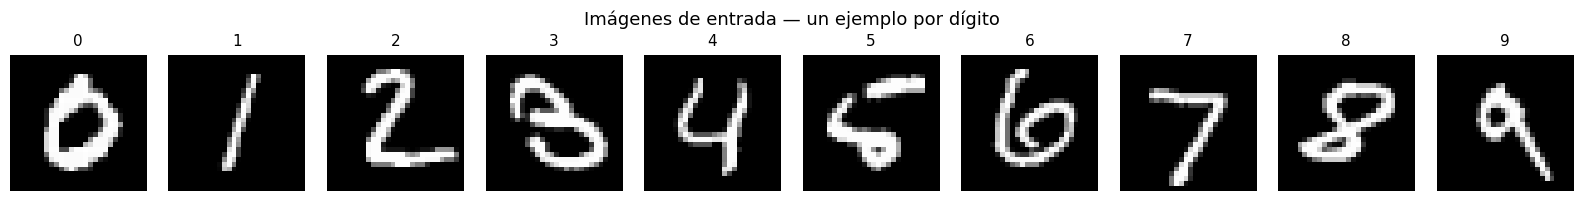

In [6]:
# Seleccionar un ejemplo de cada dígito
sample_images = []
sample_labels = []

for digit in range(10):
    idx = np.where(y_test == digit)[0][0]
    sample_images.append(X_test[idx])
    sample_labels.append(digit)

sample_images = np.array(sample_images)
print(f"Shape de sample_images: {sample_images.shape}")

# Visualizar las imágenes seleccionadas
fig, axes = plt.subplots(1, 10, figsize=(16, 2))
fig.suptitle('Imágenes de entrada — un ejemplo por dígito', fontsize=13)

for i, ax in enumerate(axes):
    ax.imshow(sample_images[i, :, :, 0], cmap='gray')
    ax.set_title(f'{i}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/03_imagenes_entrada.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
"""
## 4. Extraer activaciones intermedias

Para visualizar los feature maps necesitamos acceder a las salidas
de las capas intermedias de la red. Keras nos permite hacer esto
construyendo un "modelo intermedio" que toma la misma entrada
pero devuelve las activaciones de cualquier capa que elijamos.

Modelo original:
Input → Conv2D_1 → Pool_1 → Conv2D_2 → Pool_2 → Flatten → Dense → Output
Modelo intermedio:
Input → Conv2D_1 → Pool_1 → Conv2D_2 → Pool_2
↑                           ↑
podemos extraer              podemos extraer
activaciones acá             activaciones acá

Este enfoque se llama "feature extraction" y es la base de técnicas
más avanzadas que vamos a ver en el notebook 11.
"""

'\n## 4. Extraer activaciones intermedias\n\nPara visualizar los feature maps necesitamos acceder a las salidas\nde las capas intermedias de la red. Keras nos permite hacer esto\nconstruyendo un "modelo intermedio" que toma la misma entrada\npero devuelve las activaciones de cualquier capa que elijamos.\n\nModelo original:\nInput → Conv2D_1 → Pool_1 → Conv2D_2 → Pool_2 → Flatten → Dense → Output\nModelo intermedio:\nInput → Conv2D_1 → Pool_1 → Conv2D_2 → Pool_2\n↑                           ↑\npodemos extraer              podemos extraer\nactivaciones acá             activaciones acá\n\nEste enfoque se llama "feature extraction" y es la base de técnicas\nmás avanzadas que vamos a ver en el notebook 11.\n'

In [11]:
# Ver las capas disponibles
print("Capas del modelo:")
for i, layer in enumerate(model.layers):
    print(f"  {i}: {layer.name}")

# En Keras 3 el enfoque correcto es construir
# un modelo funcional con Input explícito
input_layer = keras.Input(shape=(28, 28, 1))

# Pasar el input por cada capa y capturar salidas de Conv2D
x = input_layer
conv_outputs = []

for layer in model.layers:
    x = layer(x)
    if isinstance(layer, layers.Conv2D):
        conv_outputs.append(x)

# Construir modelo intermedio
activation_model = Model(inputs=input_layer, outputs=conv_outputs)

print(f"\nModelo intermedio construido correctamente")
print(f"Capas convolucionales capturadas: {len(conv_outputs)}")
for i, output in enumerate(conv_outputs):
    print(f"  Conv {i+1}: {output.shape}")

Capas del modelo:
  0: conv2d
  1: max_pooling2d
  2: conv2d_1
  3: max_pooling2d_1
  4: flatten
  5: dense
  6: dense_1

Modelo intermedio construido correctamente
Capas convolucionales capturadas: 2
  Conv 1: (None, 28, 28, 32)
  Conv 2: (None, 14, 14, 64)


In [12]:
"""
## 5. Feature maps de la primera capa convolucional

La primera capa Conv2D tiene **32 filtros**, por lo tanto produce
32 feature maps para cada imagen de entrada.

Cada feature map resalta distintas características de la imagen original:
- Bordes horizontales
- Bordes verticales
- Curvas
- Esquinas

En capas tempranas los feature maps son fácilmente interpretables porque detectan características simples y locales.
En capas profundas se vuelven más abstractos y difíciles de interpretar.
"""

'\n## 5. Feature maps de la primera capa convolucional\n\nLa primera capa Conv2D tiene **32 filtros**, por lo tanto produce\n32 feature maps para cada imagen de entrada.\n\nCada feature map resalta distintas características de la imagen original:\n- Bordes horizontales\n- Bordes verticales\n- Curvas\n- Esquinas\n\nEn capas tempranas los feature maps son fácilmente interpretables porque detectan características simples y locales.\nEn capas profundas se vuelven más abstractos y difíciles de interpretar.\n'

Dígito seleccionado: 8
Shape activaciones Conv1: (28, 28, 32)
Cantidad de feature maps: 32


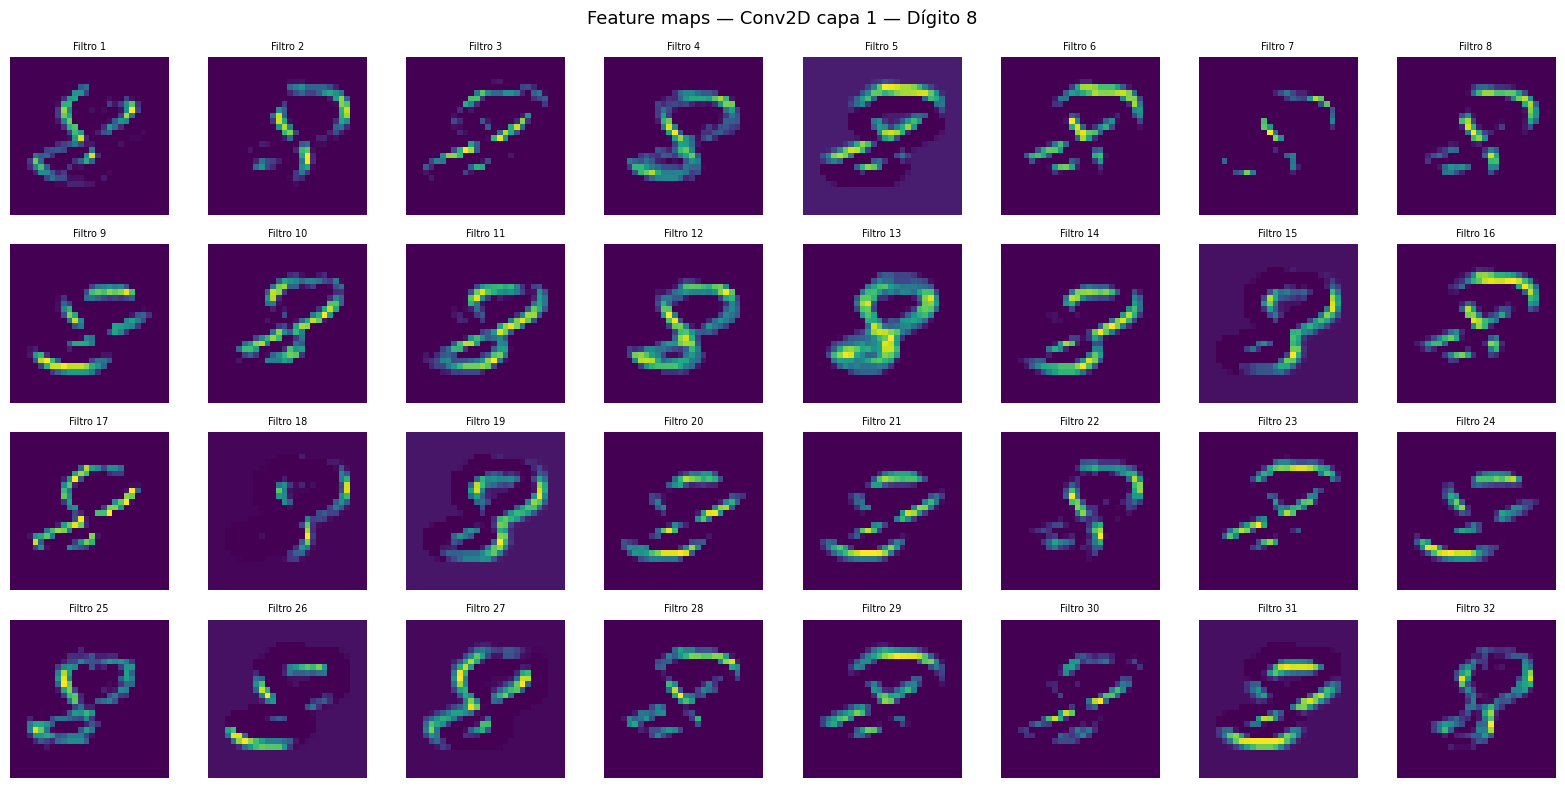

In [14]:
# Elegir un dígito para visualizar (probá cambiando este número)
digit_idx = 8  # vamos a visualizar el dígito 8

# Obtener activaciones para esa imagen
img_input = sample_images[digit_idx:digit_idx+1]  # shape: (1, 28, 28, 1)
activations = activation_model.predict(img_input, verbose=0)

# Activaciones de la primera capa conv: shape (1, 28, 28, 32)
conv1_activations = activations[0][0]  # shape: (28, 28, 32)

print(f"Dígito seleccionado: {digit_idx}")
print(f"Shape activaciones Conv1: {conv1_activations.shape}")
print(f"Cantidad de feature maps: {conv1_activations.shape[-1]}")

# Visualizar los 32 feature maps
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(f'Feature maps — Conv2D capa 1 — Dígito {digit_idx}', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(conv1_activations[:, :, i], cmap='viridis')
    ax.set_title(f'Filtro {i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/03_feature_maps_conv1.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
"""
## 6. Feature maps de la segunda capa convolucional

La segunda capa Conv2D tiene "64 filtros" y opera sobre los feature maps
de la primera capa — no sobre la imagen original.

Esto significa que detecta "combinaciones de características":
- Si la capa 1 detecta bordes, la capa 2 detecta combinaciones de bordes
- Las representaciones se vuelven más abstractas y menos interpretables visualmente
- El tamaño espacial es menor (14×14) porque ya pasó por un MaxPooling
Imagen original (28×28)
↓ Conv1 → 32 feature maps (28×28)
↓ Pool  → 32 feature maps (14×14)
↓ Conv2 → 64 feature maps (14×14)  ← estamos acá

Compará visualmente los feature maps de la capa 1 vs la capa 2, vas a notar que los de la capa 2 son más abstractas y difíciles de relacionar con partes concretas de la imagen original.

"""

'\n## 6. Feature maps de la segunda capa convolucional\n\nLa segunda capa Conv2D tiene "64 filtros" y opera sobre los feature maps\nde la primera capa — no sobre la imagen original.\n\nEsto significa que detecta "combinaciones de características":\n- Si la capa 1 detecta bordes, la capa 2 detecta combinaciones de bordes\n- Las representaciones se vuelven más abstractas y menos interpretables visualmente\n- El tamaño espacial es menor (14×14) porque ya pasó por un MaxPooling\nImagen original (28×28)\n↓ Conv1 → 32 feature maps (28×28)\n↓ Pool  → 32 feature maps (14×14)\n↓ Conv2 → 64 feature maps (14×14)  ← estamos acá\n\nCompará visualmente los feature maps de la capa 1 vs la capa 2, vas a notar que los de la capa 2 son más abstractas y difíciles de relacionar con partes concretas de la imagen original.\n\n'

Shape activaciones Conv2: (14, 14, 64)
Cantidad de feature maps: 64


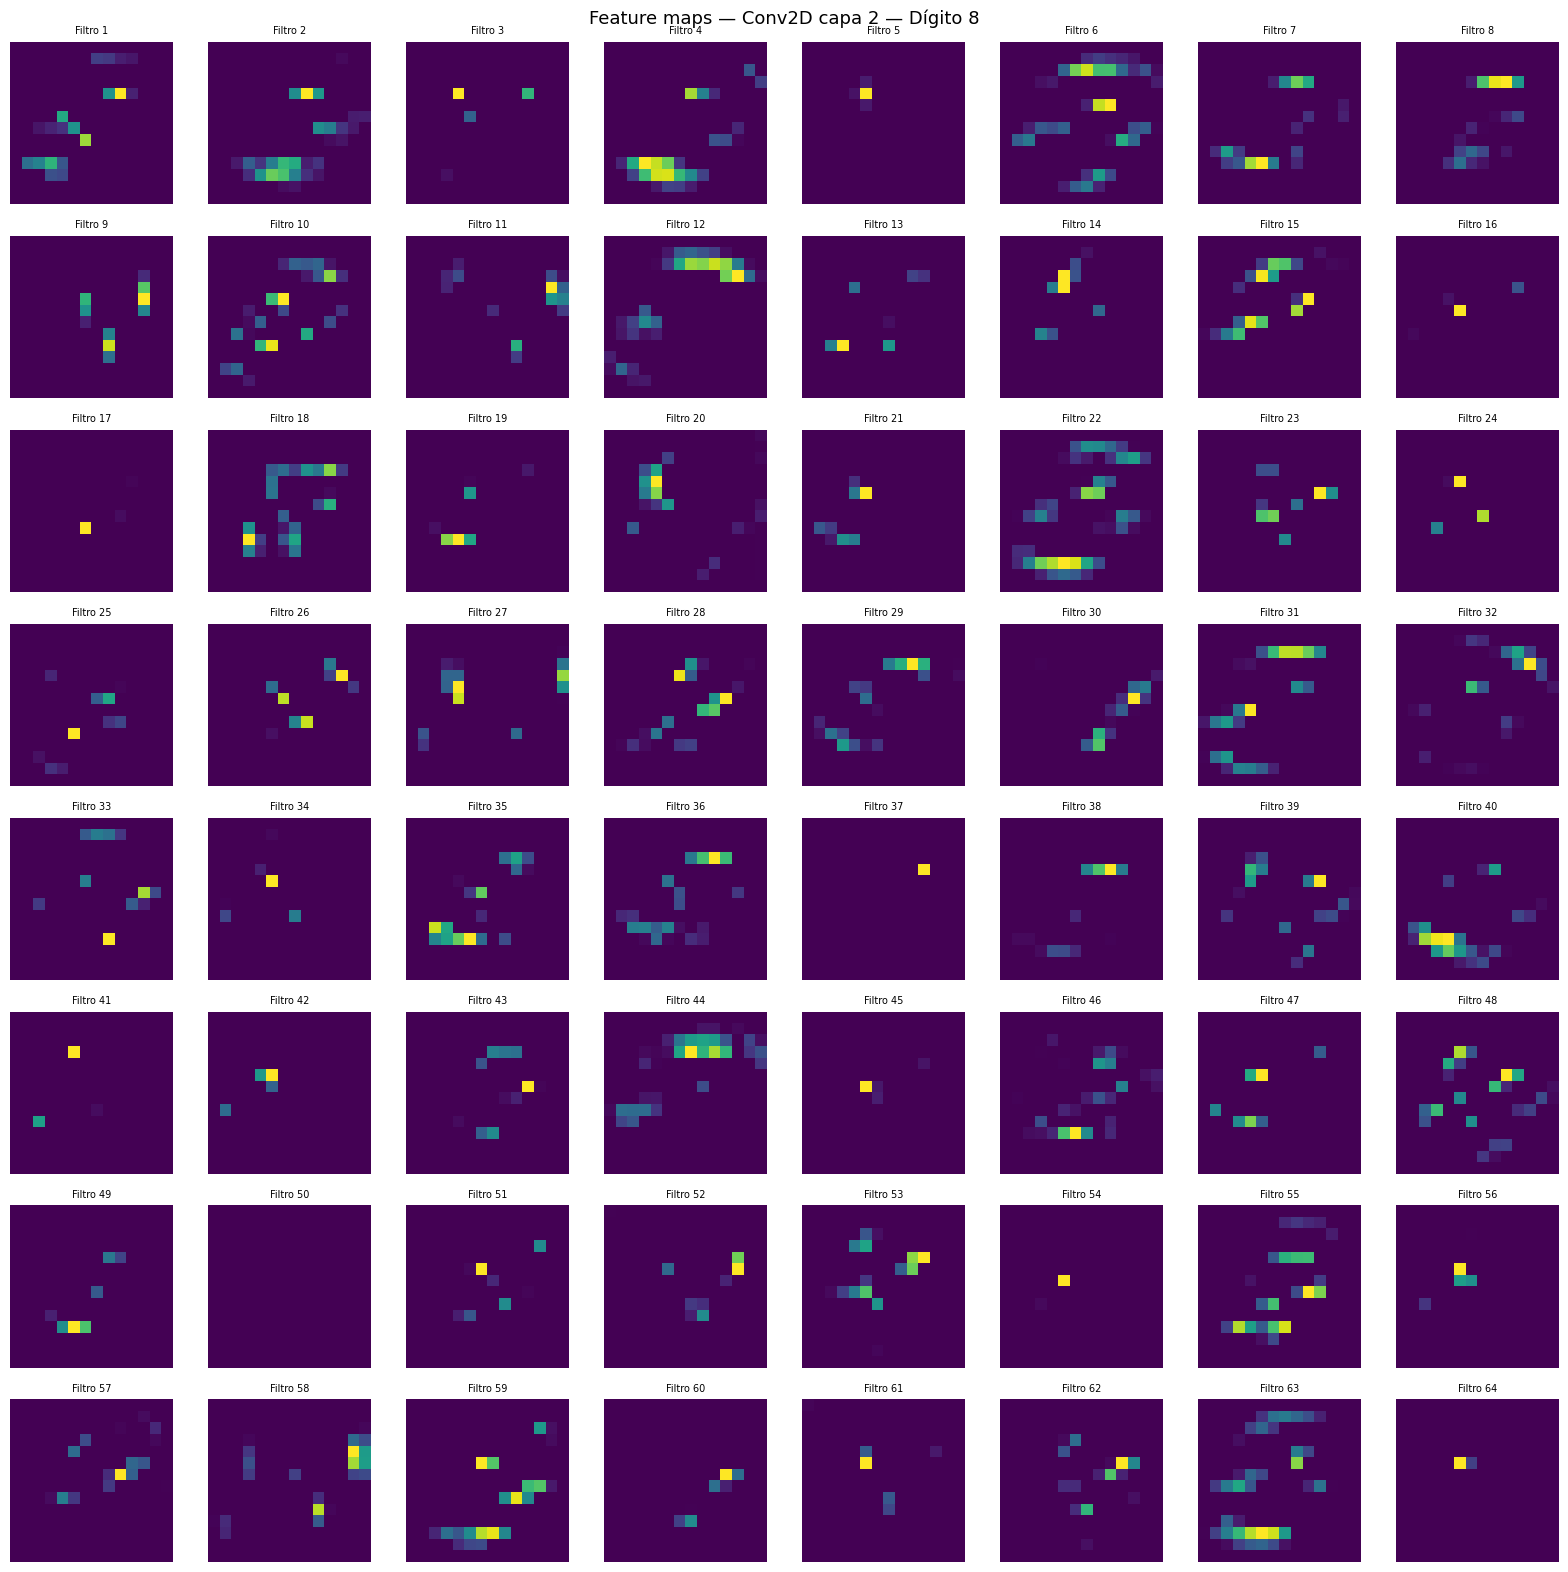

In [16]:
# Activaciones de la segunda capa conv: shape (1, 14, 14, 64)
conv2_activations = activations[1][0]  # shape: (14, 14, 64)

print(f"Shape activaciones Conv2: {conv2_activations.shape}")
print(f"Cantidad de feature maps: {conv2_activations.shape[-1]}")

# Visualizar los 64 feature maps
fig, axes = plt.subplots(8, 8, figsize=(16, 16))
fig.suptitle(f'Feature maps — Conv2D capa 2 — Dígito {digit_idx}', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(conv2_activations[:, :, i], cmap='viridis')
    ax.set_title(f'Filtro {i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/03_feature_maps_conv2.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
"""
## 7. Comparar feature maps entre distintos dígitos

Hasta ahora visualizamos los feature maps de un solo dígito.
Ahora vamos a comparar cómo los "mismos filtros" responden
de forma distinta ante diferentes imágenes de entrada.

Vamos a tomar un filtro específico de la capa 1 y ver cómo
activa para cada uno de los 10 dígitos — esto nos da intuición
sobre qué característica específica detecta ese filtro.

Un filtro que detecta curvas va a activar fuerte ante el 0, 6, 8 y 9 pero débil ante el 1 y el 7. Eso es exactamente lo que hace útil a una CNN para distinguir entre clases.
"""

'\n## 7. Comparar feature maps entre distintos dígitos\n\nHasta ahora visualizamos los feature maps de un solo dígito.\nAhora vamos a comparar cómo los "mismos filtros" responden\nde forma distinta ante diferentes imágenes de entrada.\n\nVamos a tomar un filtro específico de la capa 1 y ver cómo\nactiva para cada uno de los 10 dígitos — esto nos da intuición\nsobre qué característica específica detecta ese filtro.\n\nUn filtro que detecta curvas va a activar fuerte ante el 0, 6, 8 y 9 pero débil ante el 1 y el 7. Eso es exactamente lo que hace útil a una CNN para distinguir entre clases.\n'

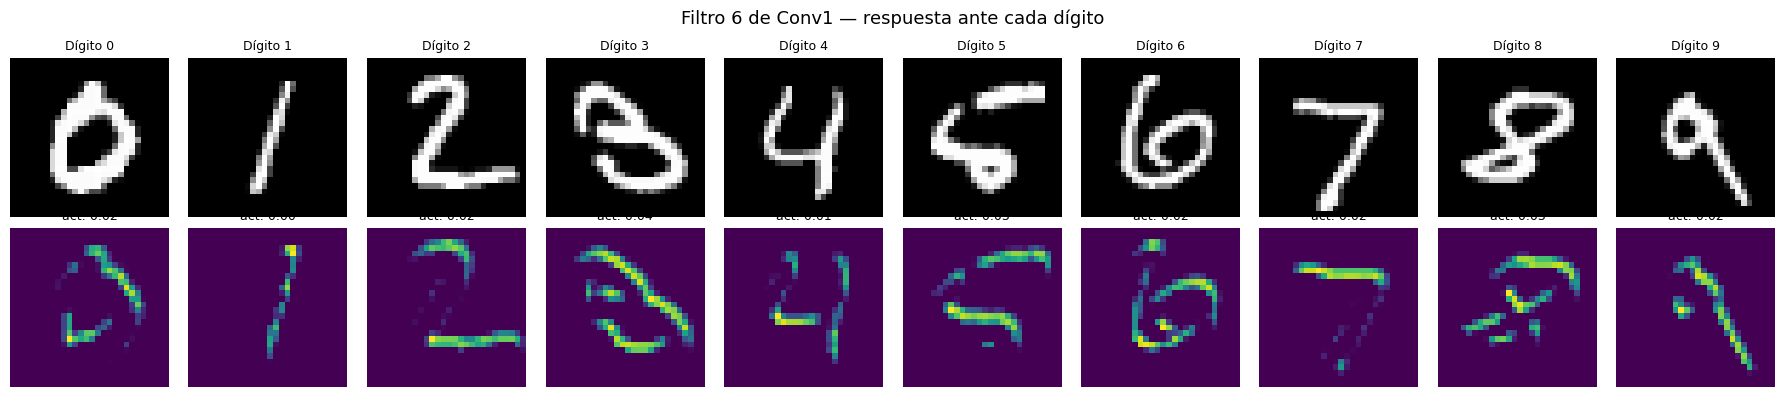

Fila 1: imagen original | Fila 2: activación del filtro seleccionado
'act' = activación promedio — cuanto mayor, más responde el filtro a ese dígito


In [18]:
# Obtener activaciones para todos los dígitos
all_activations = activation_model.predict(sample_images, verbose=0)

# Elegir un filtro específico para comparar (probá cambiando este número)
filtro_idx = 5  # filtro número 5 de la capa 1

# Visualizar ese filtro para los 10 dígitos
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle(f'Filtro {filtro_idx+1} de Conv1 — respuesta ante cada dígito', fontsize=13)

for digit in range(10):
    # Imagen original
    axes[0, digit].imshow(sample_images[digit, :, :, 0], cmap='gray')
    axes[0, digit].set_title(f'Dígito {digit}', fontsize=9)
    axes[0, digit].axis('off')

    # Feature map del filtro seleccionado
    fmap = all_activations[0][digit, :, :, filtro_idx]
    axes[1, digit].imshow(fmap, cmap='viridis')
    axes[1, digit].set_title(f'act: {fmap.mean():.2f}', fontsize=9)
    axes[1, digit].axis('off')

plt.tight_layout()
plt.savefig('../figures/03_comparacion_digitos.png', dpi=120, bbox_inches='tight')
plt.show()

print("Fila 1: imagen original | Fila 2: activación del filtro seleccionado")
print("'act' = activación promedio — cuanto mayor, más responde el filtro a ese dígito")

In [19]:
"""
## 8. Visualizar los pesos de los filtros

Hasta ahora visualizamos las "activaciones" — el resultado de aplicar
los filtros sobre una imagen. Ahora vamos a ver los "pesos" de los
filtros en sí mismos — los valores que la red aprendió durante el entrenamiento.
Pesos del filtro (3×3)    Imagen de entrada    Feature map
┌─────────────┐           ┌───────────┐         ┌──────────┐
│ -1  -1  -1  │           │  0  1  0  │         │          │
│  0   0   0  │     *     │  1  1  1  │    =    │  result  │
│  1   1   1  │           │  0  1  0  │         │          │
└─────────────┘           └───────────┘         └──────────┘
Lo que aprendió              Input               Output
la red

Los pesos son independientes de la imagen de entrada — son los mismos para cualquier imagen. Lo que cambia es el feature map resultante.
"""

'\n## 8. Visualizar los pesos de los filtros\n\nHasta ahora visualizamos las "activaciones" — el resultado de aplicar\nlos filtros sobre una imagen. Ahora vamos a ver los "pesos" de los\nfiltros en sí mismos — los valores que la red aprendió durante el entrenamiento.\nPesos del filtro (3×3)    Imagen de entrada    Feature map\n┌─────────────┐           ┌───────────┐         ┌──────────┐\n│ -1  -1  -1  │           │  0  1  0  │         │          │\n│  0   0   0  │     *     │  1  1  1  │    =    │  result  │\n│  1   1   1  │           │  0  1  0  │         │          │\n└─────────────┘           └───────────┘         └──────────┘\nLo que aprendió              Input               Output\nla red\n\nLos pesos son independientes de la imagen de entrada — son los mismos para cualquier imagen. Lo que cambia es el feature map resultante.\n'

Shape de los pesos Conv1: (3, 3, 1, 32)
Interpretación: 3×3 kernel | 1 canal entrada | 32 filtros


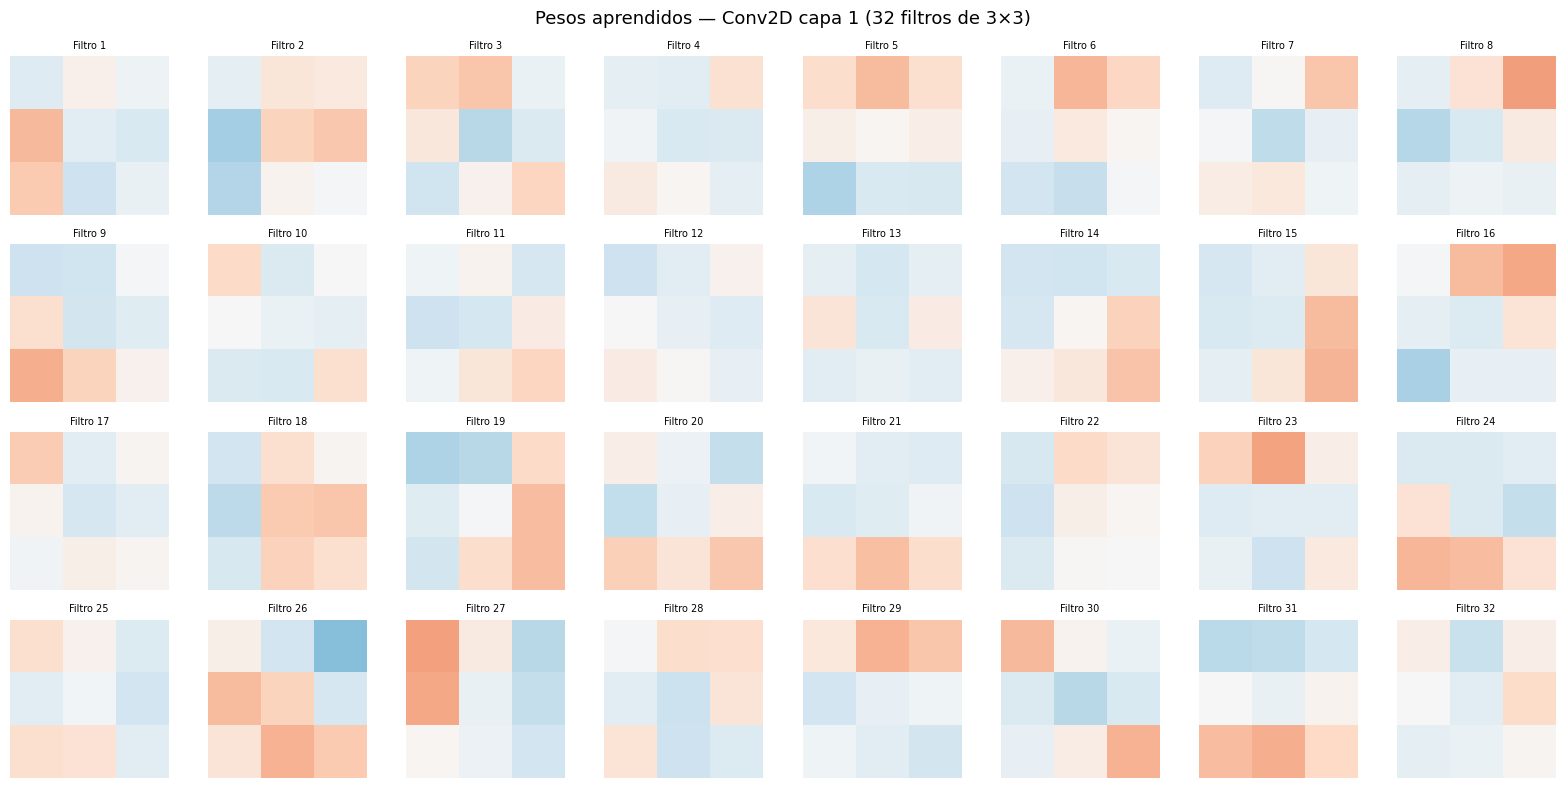

Rojo = pesos positivos | Azul = pesos negativos | Blanco = cercano a cero


In [20]:
# Extraer pesos de la primera capa convolucional
# shape: (3, 3, 1, 32) → (alto, ancho, canales_entrada, n_filtros)
conv1_weights = model.layers[0].get_weights()[0]

print(f"Shape de los pesos Conv1: {conv1_weights.shape}")
print(f"Interpretación: {conv1_weights.shape[0]}×{conv1_weights.shape[1]} kernel | "
      f"{conv1_weights.shape[2]} canal entrada | "
      f"{conv1_weights.shape[3]} filtros")

# Visualizar los 32 filtros aprendidos
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Pesos aprendidos — Conv2D capa 1 (32 filtros de 3×3)', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    kernel = conv1_weights[:, :, 0, i]  # shape: (3, 3)
    ax.imshow(kernel, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_title(f'Filtro {i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/03_pesos_filtros.png', dpi=120, bbox_inches='tight')
plt.show()

print("Rojo = pesos positivos | Azul = pesos negativos | Blanco = cercano a cero")

In [21]:
"""
## 9. Comparar imagen original vs activaciones por capa

Para cerrar el notebook vamos a hacer una visualización completa
que muestre el recorrido de una imagen a través de la red:
Imagen        Feature maps    Feature maps
original  →   Conv1 (28×28) → Conv2 (14×14)
(28×28)       32 mapas        64 mapas

Esto nos permite ver de forma clara cómo la red transforma
progresivamente la representación de la imagen — desde píxeles
crudos hasta representaciones abstractas listas para clasificar.

Este recorrido es la esencia de lo que hace poderoso al deep learning: cada capa construye representaciones más abstractas sobre las representaciones de la capa anterior.
"""

'\n## 9. Comparar imagen original vs activaciones por capa\n\nPara cerrar el notebook vamos a hacer una visualización completa\nque muestre el recorrido de una imagen a través de la red:\nImagen        Feature maps    Feature maps\noriginal  →   Conv1 (28×28) → Conv2 (14×14)\n(28×28)       32 mapas        64 mapas\n\nEsto nos permite ver de forma clara cómo la red transforma\nprogresivamente la representación de la imagen — desde píxeles\ncrudos hasta representaciones abstractas listas para clasificar.\n\nEste recorrido es la esencia de lo que hace poderoso al deep learning: cada capa construye representaciones más abstractas sobre las representaciones de la capa anterior.\n'

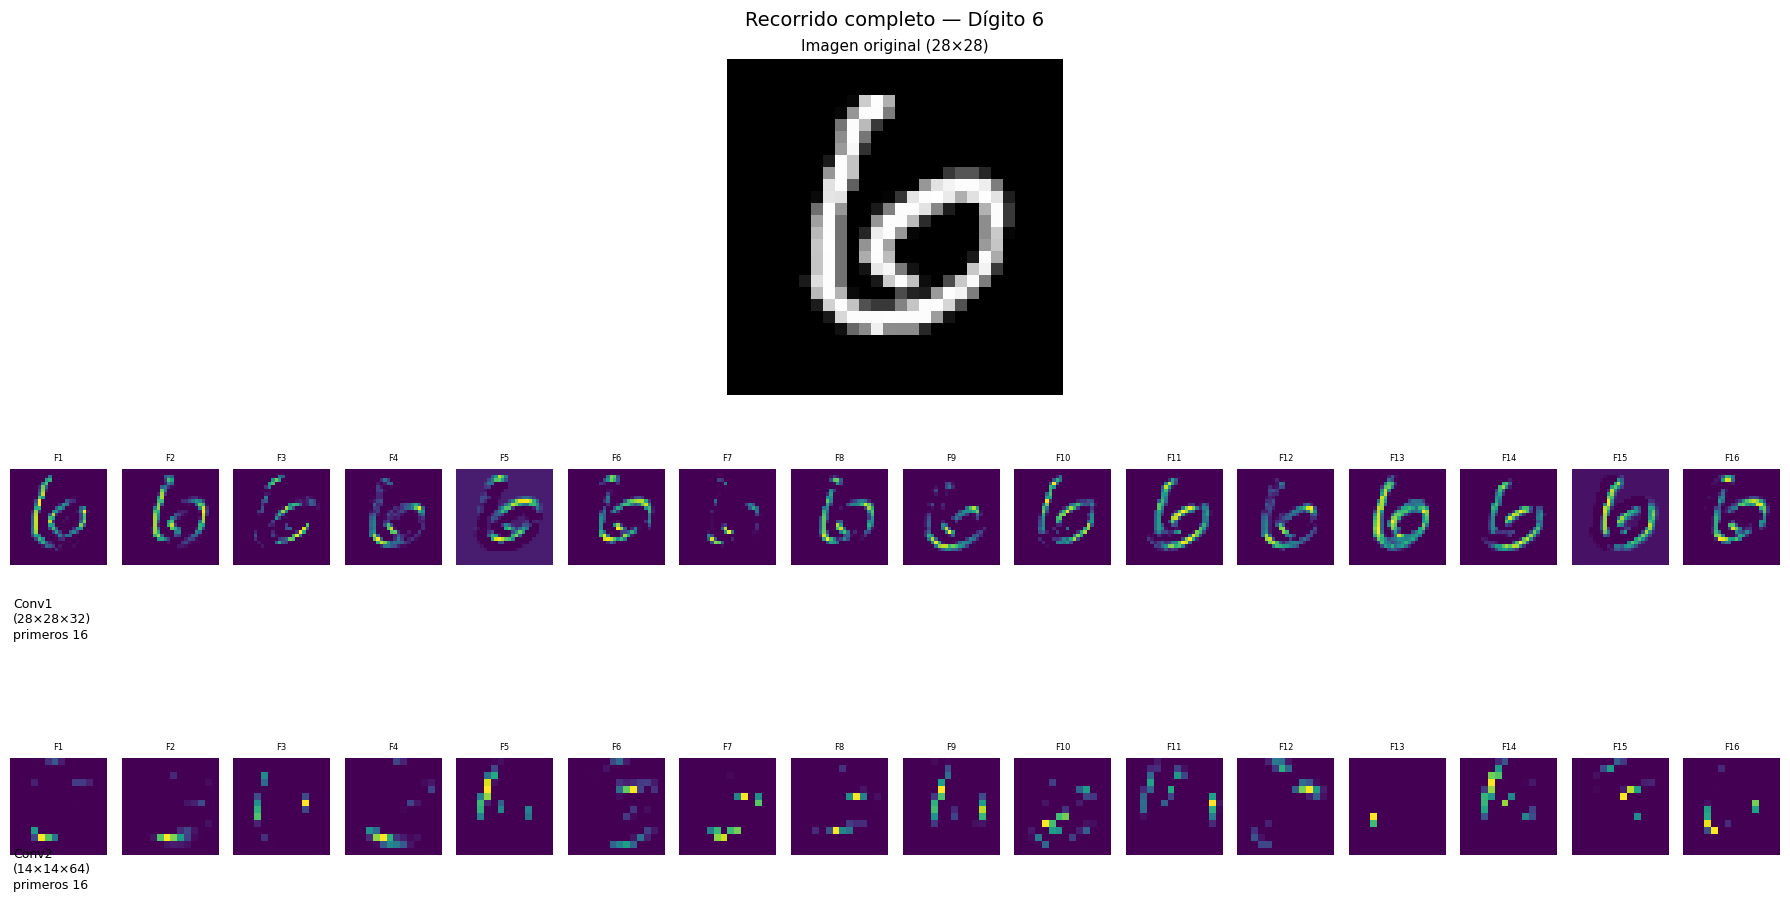

In [22]:
# Elegir un dígito para el recorrido completo
digit_idx = 6  # probá cambiando este número

img_input = sample_images[digit_idx:digit_idx+1]
activations = activation_model.predict(img_input, verbose=0)

conv1_act = activations[0][0]  # (28, 28, 32)
conv2_act = activations[1][0]  # (14, 14, 64)

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f'Recorrido completo — Dígito {digit_idx}', fontsize=14)

# --- Imagen original ---
ax_orig = fig.add_subplot(3, 1, 1)
ax_orig.imshow(sample_images[digit_idx, :, :, 0], cmap='gray')
ax_orig.set_title('Imagen original (28×28)', fontsize=11)
ax_orig.axis('off')

# --- Feature maps Conv1 (primeros 16) ---
for i in range(16):
    ax = fig.add_subplot(3, 16, 16 + i + 1)
    ax.imshow(conv1_act[:, :, i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=6)
    ax.axis('off')

# Etiqueta Conv1
fig.text(0.01, 0.37, 'Conv1\n(28×28×32)\nprimeros 16', fontsize=9, va='center')

# --- Feature maps Conv2 (primeros 16) ---
for i in range(16):
    ax = fig.add_subplot(3, 16, 32 + i + 1)
    ax.imshow(conv2_act[:, :, i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=6)
    ax.axis('off')

# Etiqueta Conv2
fig.text(0.01, 0.12, 'Conv2\n(14×14×64)\nprimeros 16', fontsize=9, va='center')

plt.tight_layout()
plt.savefig('../figures/03_recorrido_completo.png', dpi=120, bbox_inches='tight')
plt.show()

In [23]:
"""
## Resumen del notebook
| Concepto | Lo que aprendimos |
|---|---|
| "Feature map" | El resultado de aplicar un filtro sobre una imagen |
| "Capas tempranas" | Detectan características simples: bordes, curvas, líneas |
| "Capas profundas" | Detectan características abstractas: combinaciones de patrones |
| "Pesos vs activaciones" | Los pesos son fijos, las activaciones dependen de la imagen |
| "Modelo intermedio" | `Model(inputs, outputs)` para extraer activaciones internas |
| "Jerarquía de representaciones" | Cada capa construye sobre las representaciones de la anterior |
---
## ¿Qué sigue?
En el "notebook 04" vamos a comparar las características aprendidas
por una CNN contra las características clásicas de visión por computadora
(HOG, LBP, SIFT) — esto nos va a dar una perspectiva clara de por qué
el deep learning superó a los métodos tradicionales.
---
"Módulo 05 — Deep Learning para Clasificación | TensorFlow / Keras"
"""

'\n## Resumen del notebook\n| Concepto | Lo que aprendimos |\n|---|---|\n| "Feature map" | El resultado de aplicar un filtro sobre una imagen |\n| "Capas tempranas" | Detectan características simples: bordes, curvas, líneas |\n| "Capas profundas" | Detectan características abstractas: combinaciones de patrones |\n| "Pesos vs activaciones" | Los pesos son fijos, las activaciones dependen de la imagen |\n| "Modelo intermedio" | `Model(inputs, outputs)` para extraer activaciones internas |\n| "Jerarquía de representaciones" | Cada capa construye sobre las representaciones de la anterior |\n---\n## ¿Qué sigue?\nEn el "notebook 04" vamos a comparar las características aprendidas\npor una CNN contra las características clásicas de visión por computadora\n(HOG, LBP, SIFT) — esto nos va a dar una perspectiva clara de por qué\nel deep learning superó a los métodos tradicionales.\n---\n"Módulo 05 — Deep Learning para Clasificación | TensorFlow / Keras"\n'